# Analisis Prediksi Permintaan Listrik Harian dengan Skforecast dan LightGBM

## Deskripsi Proyek

Proyek ini bertujuan untuk memprediksi permintaan listrik harian di Victoria, Australia menggunakan metode forecasting berbasis machine learning. Model dibangun dengan memanfaatkan algoritma **LightGBM** yang diimplementasikan melalui library **Skforecast**.

Selain menghasilkan prediksi, proyek ini juga menerapkan konsep **Explainable Artificial Intelligence (XAI)** untuk memahami bagaimana model membuat keputusan. Teknik interpretasi yang digunakan meliputi **Feature Importance**, **SHAP Values**, **Permutation Importance**, dan **Partial Dependence Plot (PDP)**.

### Teknologi yang Digunakan

* **Skforecast** sebagai framework forecasting berbasis Scikit-Learn
* **LightGBM** sebagai algoritma machine learning utama
* **SHAP** dan **Permutation Importance** untuk interpretasi model

### Tujuan Analisis

Memprediksi total permintaan listrik harian berdasarkan pola historis permintaan listrik dan suhu rata-rata harian, serta memahami faktor-faktor yang memengaruhi hasil prediksi.

### Pentingnya Explainable AI

Model prediksi yang hanya menghasilkan angka sering kali sulit dipahami dan dipercaya. Dengan Explainable AI, kita dapat mengetahui fitur yang paling berpengaruh, arah pengaruhnya terhadap prediksi, serta alasan model menghasilkan prediksi tertentu.


# Alur dan Proses Analisis

Pada tahap ini dilakukan serangkaian proses untuk membangun model prediksi permintaan listrik harian menggunakan Skforecast dan LightGBM. Proses dimulai dari pengambilan dan persiapan dataset, dilanjutkan dengan pembentukan fitur lag dan pembagian data menjadi data training serta testing. Setelah model dilatih, dilakukan proses prediksi dan evaluasi menggunakan berbagai teknik Explainable AI seperti Feature Importance, SHAP Values, Permutation Importance, dan Partial Dependence Plot (PDP). Tahapan ini bertujuan untuk menghasilkan prediksi yang akurat sekaligus memberikan pemahaman mengenai faktor-faktor yang memengaruhi hasil prediksi.

## Langkah 1 - Instalasi Library

Install library `skforecast` versi 0.15.0 yang dibutuhkan untuk menjalankan notebook ini.

Penting: pastikan versi yang diinstall sesuai (0.15.0) karena API dan struktur fungsi antar versi Skforecast dapat berbeda secara signifikan.

In [70]:
pip install skforecast==0.15.0

**Hasil Output:**

Output menampilkan proses instalasi `skforecast==0.15.0` beserta seluruh dependensinya. Karena environment sudah memiliki library tersebut, setiap baris diawali dengan `Requirement already satisfied`, yang berarti tidak ada proses pengunduhan ulang. Library pendukung yang terinstall antara lain `numpy`, `pandas`, `scikit-learn`, `lightgbm`, `optuna`, `joblib`, `numba`, dan `rich`. Instalasi dinyatakan berhasil tanpa error.

## Langkah 2 - Import Library

Berikut adalah library yang digunakan beserta fungsinya masing-masing:

| Library | Fungsi |
|---|---|
| `pandas` | Manipulasi dan analisis data tabular (DataFrame) |
| `matplotlib.pyplot` | Membuat visualisasi grafik |
| `shap` | Menghitung dan memvisualisasikan SHAP values untuk explainability |
| `sklearn.inspection.permutation_importance` | Mengukur kepentingan fitur dengan metode permutasi |
| `sklearn.inspection.PartialDependenceDisplay` | Membuat Partial Dependence Plot (PDP) |
| `lightgbm.LGBMRegressor` | Model LightGBM untuk tugas regresi |
| `skforecast.datasets.fetch_dataset` | Mengunduh dataset bawaan Skforecast |
| `skforecast.recursive.ForecasterRecursive` | Membangun forecaster rekursif berbasis scikit-learn |

In [71]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Langkah 3 - Memuat Dataset

**Dataset: vic_electricity**

Dataset ini berisi data konsumsi listrik di negara bagian Victoria, Australia, dengan interval waktu setiap 30 menit.

Kolom utama dalam dataset:
| Kolom | Tipe | Keterangan |
|---|---|---|
| `Demand` | float | Total permintaan listrik dalam MWh per interval |
| `Temperature` | float | Suhu udara rata-rata dalam derajat Celsius |
| Index | DatetimeIndex | Timestamp waktu dengan frekuensi 30 menit |

Dataset diambil langsung dari repositori bawaan Skforecast menggunakan fungsi `fetch_dataset`, sehingga tidak perlu mengunduh file secara manual.

In [72]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


**Hasil Output:**

Dataset `vic_electricity` berhasil diunduh. Output menampilkan informasi dataset:

- Sumber: O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022), tsibbledata
- Ukuran dataset: **52.608 baris x 4 kolom**
- Frekuensi: setiap 30 menit
- Kolom: `Demand`, `Temperature`, `Date`, `Holiday`
- Tiga baris pertama yang ditampilkan

Terlihat bahwa nilai Demand per interval 30 menit berkisar di angka 4.000 MWh, dan data dimulai dari akhir Desember 2011.

## Langkah 4 - Agregasi Data ke Frekuensi Harian

Data asli memiliki granularitas 30 menit (48 baris per hari). Untuk menyederhanakan analisis, data di-resample menjadi frekuensi **harian**.

Metode agregasi:
| Kolom | Metode | Alasan |
|---|---|---|
| `Demand` | `sum` (penjumlahan) | Total konsumsi listrik per hari |
| `Temperature` | `mean` (rata-rata) | Suhu rata-rata harian |

Hasil agregasi ini mengurangi noise jangka pendek dan membuat pola seasonal harian/mingguan lebih mudah dipelajari oleh model.

In [73]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


**Hasil Output:**

Setelah agregasi harian, data berhasil dikompresi dari 52.608 baris menjadi jumlah hari. Output menampilkan Tiga baris pertama hasil agregasi.

Terlihat perbedaan signifikan antara 31 Desember (hanya setengah hari karena data mulai pukul 13.00) dengan 1-2 Januari yang sudah penuh 24 jam. Nilai Demand harian berkisar antara 150.000 hingga 300.000 MWh, dan suhu di atas 30 derajat (seperti 2 Januari) berkorelasi dengan demand yang tinggi.

## Langkah 5 - Pembagian Data Training dan Testing

Data dibagi menjadi dua bagian:
- **Data Training**: periode hingga 21 Desember 2014 — digunakan untuk melatih model
- **Data Testing**: periode mulai 22 Desember 2014 ke atas — digunakan untuk mengevaluasi prediksi

**Penting:** Pembagian ini menggunakan **time-series split**, bukan random split.

Pada data time series, urutan waktu harus dijaga. Jika kita memecah data secara acak, model akan 'melihat masa depan' saat training (data leakage), sehingga evaluasi menjadi tidak valid. Oleh karena itu, data training selalu berada di awal (masa lalu) dan data testing di akhir (masa depan).

In [74]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

**Hasil Output:**

Cell ini tidak menghasilkan output visual. Dua variabel baru terbentuk: `data_train` berisi seluruh data hingga 21 Desember 2014, dan `data_test` berisi data mulai 22 Desember 2014. Pembagian ini memastikan model tidak pernah melihat data test saat proses training.

## Langkah 6 - Membangun dan Melatih Forecaster

ForecasterRecursive adalah pendekatan forecasting multi-step di mana prediksi dilakukan secara rekursif: prediksi pada langkah pertama (t+1) digunakan sebagai input untuk memprediksi langkah kedua (t+2), dan seterusnya hingga jumlah langkah yang ditentukan.

**Konfigurasi Forecaster:**

- `regressor = LGBMRegressor(random_state=123, verbose=-1)`
  Model yang digunakan adalah LightGBM, yaitu algoritma gradient boosting yang efisien dan akurat untuk data tabular.

- `lags = 7`
  Model menggunakan 7 nilai historis (lag) sebagai fitur input.

**Pengunaan Lag:**

Lag adalah nilai variabel target dari masa lalu yang dijadikan fitur (input) untuk memprediksi nilai saat ini. Konsep ini mengubah masalah forecasting time series menjadi masalah regresi standar.

Dengan `lags = 7`, model membuat 7 fitur baru.

**Intuisi pemilihan lag 7:**

Permintaan listrik memiliki pola mingguan yang kuat — hari Senin cenderung mirip dengan Senin sebelumnya. Dengan lag 7, model mampu menangkap siklus mingguan tersebut.

Selain lag, model juga menerima **exogenous variable** (variabel eksogen):
- `Temperature` — suhu rata-rata harian, yang secara intuitif mempengaruhi penggunaan AC dan pemanas listrik.

In [75]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Exogenous included: True 
Exogenous names: Temperature 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 13:20:25 
Last fit date: 2026-06-10 13:20:25 
Skforecast version: 0.15.0 
Python version: 3.12.13 
Forecaster id: None

**Hasil Output:**

Output menampilkan ringkasan konfigurasi `ForecasterRecursive` yang berhasil dibuat dan dilatih  tanpa error. Konfirmasi `Exogenous included: True` menunjukkan bahwa Temperature ikut digunakan sebagai fitur input.

## Langkah 7 - Feature Importance Bawaan LightGBM

Setelah model dilatih, dapat langsung melihat kepentingan fitur menggunakan metode bawaan LightGBM.

Metode yang digunakan adalah **gain**, yaitu seberapa besar kontribusi suatu fitur dalam mengurangi loss/error saat model membangun pohon keputusan (decision tree) di dalam ensemble-nya.

Semakin tinggi nilai gain suatu fitur, semakin penting fitur tersebut dalam proses prediksi.

Fitur yang dianalisis: `lag_1` hingga `lag_7` dan `Temperature`.

Catatan: Feature importance bawaan model bersifat global (menggambarkan kepentingan rata-rata di seluruh data training) dan berbasis struktur pohon internal, bukan berdasarkan perubahan performa aktual.

In [76]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


**Hasil Output:**

Tabel feature importance dari LightGBM (berbasis gain), diurutkan dari yang tertinggi.

Interpretasi:
- `Temperature` menjadi fitur paling penting (570), menunjukkan bahwa suhu udara adalah faktor dominan dalam menentukan permintaan listrik harian. Hal ini masuk akal karena suhu tinggi mendorong penggunaan AC dan suhu rendah mendorong penggunaan pemanas.
- `lag_1` (kemarin) berada di urutan kedua (470), artinya permintaan hari sebelumnya adalah prediktor historis terkuat.
- `lag_3` dan `lag_2` lebih tinggi dari `lag_7`, menunjukkan pola jangka pendek (3 hari terakhir) lebih relevan dibanding pola mingguan dalam dataset ini.

## Langkah 8 - Melihat Struktur Matriks Data Training

Bagian ini menampilkan secara eksplisit bagaimana Skforecast mentransformasi data time series menjadi format matriks untuk pelatihan model regresi.

**Input Model (X_train)**

Setiap baris mewakili satu hari yang akan diprediksi, dengan fitur:
| Kolom | Deskripsi |
|---|---|
| `lag_1` | Nilai Demand pada hari t-1 |
| `lag_2` | Nilai Demand pada hari t-2 |
| `lag_3` | Nilai Demand pada hari t-3 |
| `lag_4` | Nilai Demand pada hari t-4 |
| `lag_5` | Nilai Demand pada hari t-5 |
| `lag_6` | Nilai Demand pada hari t-6 |
| `lag_7` | Nilai Demand pada hari t-7 |
| `Temperature` | Suhu rata-rata pada hari t (exogenous variable) |

**Output Model (y_train)**

| Kolom | Deskripsi |
|---|---|
| `Demand` | Nilai permintaan listrik aktual pada hari t |

**Contoh Logika Satu Baris Data Training**

```
Jika:
  lag_1 = 180,000 MWh  (kemarin)
  lag_2 = 175,000 MWh  (2 hari lalu)
  ....
  lag_7 = 182,000 MWh  (7 hari lalu)
  Temperature = 22.5 C (suhu hari ini)
Maka model belajar untuk memprediksi:
  Demand = 178,500 MWh (permintaan listrik hari ini)
```

Proses ini mengubah masalah time series menjadi masalah supervised learning standar.

In [77]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


**Hasil Output:**

Output menampilkan dua tabel masing-masing 3 baris pertama dari: X_train (input) dan y_train (output).

Interpretasi:

Dapat diamati bahwa nilai `lag_1` pada baris 2012-01-08 sama persis dengan nilai target (`y`) pada baris 2012-01-07 (200.693,27). Ini membuktikan bahwa Skforecast secara otomatis dan benar menggeser nilai Demand satu hari ke depan untuk membentuk lag. Data training dimulai dari 7 Januari 2012 karena 7 baris pertama habis digunakan untuk membentuk lag_1 hingga lag_7.

## Langkah 9 - SHAP: Membangun Explainer
SHAP (SHapley Additive exPlanations) adalah metode untuk menjelaskan prediksi model machine learning secara kuantitatif. SHAP didasarkan pada konsep **Shapley values** dari teori permainan (game theory), yang secara adil mendistribusikan 'kredit' kontribusi kepada setiap fitur.

Cara Kerja SHAP:

Untuk setiap prediksi, SHAP menghitung seberapa besar setiap fitur menggeser prediksi dari nilai rata-rata baseline (expected value) ke nilai prediksi aktual:

```
prediksi = baseline + SHAP(lag_1) + SHAP(lag_2) + ... + SHAP(lag_7) + SHAP(Temperature)
```

- Nilai SHAP positif: fitur mendorong prediksi naik (meningkatkan demand)
- Nilai SHAP negatif: fitur mendorong prediksi turun (menurunkan demand)

`shap.TreeExplainer` adalah varian SHAP yang dioptimasi khusus untuk model berbasis pohon keputusan (tree-based models) seperti LightGBM, XGBoost, dan Random Forest. Lebih cepat dan akurat dibanding metode SHAP umum untuk jenis model ini.

In [78]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_train)

**Hasil Output:**

Cell ini menghasilkan icon JavaScript kecil dari `shap.initjs()` yang menandakan library SHAP berhasil diinisialisasi untuk rendering visualisasi interaktif. Objek `explainer` dan `shap_values` berhasil dibuat tanpa error. `shap_values` adalah array berukuran sama dengan X_train yang berisi nilai SHAP untuk setiap fitur di setiap observasi training.

## Langkah 10 - SHAP Summary Plot: Bar Chart (Global Importance)

Plot ini menampilkan **rata-rata nilai absolut SHAP** untuk setiap fitur di seluruh data training.

Interpretasi:
- Semakin panjang bar suatu fitur, semakin besar rata-rata pengaruhnya terhadap prediksi
- Bar chart ini bersifat global: merangkum kepentingan fitur di semua prediksi training
- Tidak menunjukkan arah pengaruh (positif/negatif), hanya besarnya

Pada dataset ini, umumnya `lag_1` dan `Temperature` tampil sebagai fitur dengan pengaruh terbesar.

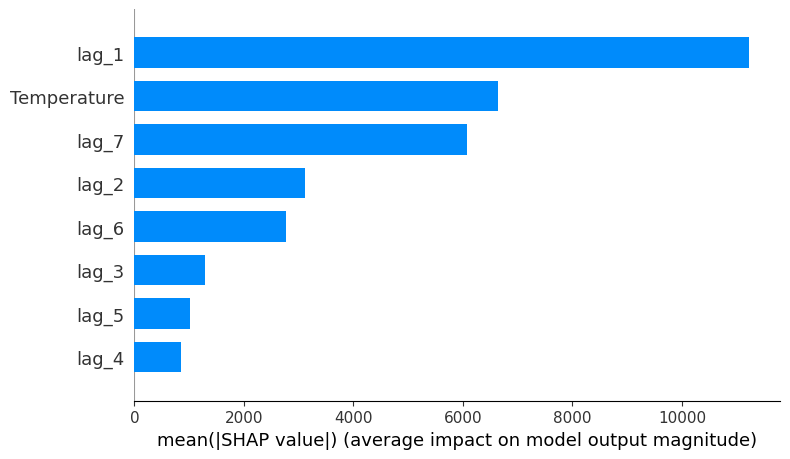

In [79]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

**Hasil Output:**

Bar chart horizontal menampilkan rata-rata absolut SHAP value (mean(|SHAP value|)) untuk setiap fitur, diurutkan dari yang terbesar.

Berbeda dengan feature importance LightGBM sebelumnya yang menempatkan Temperature di urutan 1, SHAP menempatkan `lag_1` sebagai fitur dengan rata-rata pengaruh terbesar terhadap output prediksi. Ini menunjukkan bahwa meskipun Temperature sering digunakan model (gain tinggi), besarnya pergeseran prediksi yang disebabkan oleh `lag_1` secara rata-rata lebih besar. Kedua metrik mengukur hal yang sedikit berbeda, dan keduanya saling melengkapi.

## Langkah 11 - SHAP Summary Plot: Beeswarm Plot (Distribusi Pengaruh)

Plot ini lebih informatif dari bar chart karena menampilkan distribusi SHAP value untuk setiap fitur.

Cara membaca plot:
- Setiap titik mewakili satu observasi dari data training
- Sumbu horizontal: nilai SHAP (positif = mendorong demand naik, negatif = mendorong demand turun)
- Warna titik: merah = nilai fitur tinggi, biru = nilai fitur rendah

Contoh interpretasi:
- Jika titik merah pada `Temperature` berada di sisi kanan (SHAP positif): suhu tinggi meningkatkan prediksi demand (kemungkinan karena penggunaan AC)
- Jika titik biru pada `Temperature` berada di sisi kiri (SHAP negatif): suhu rendah menurunkan prediksi demand

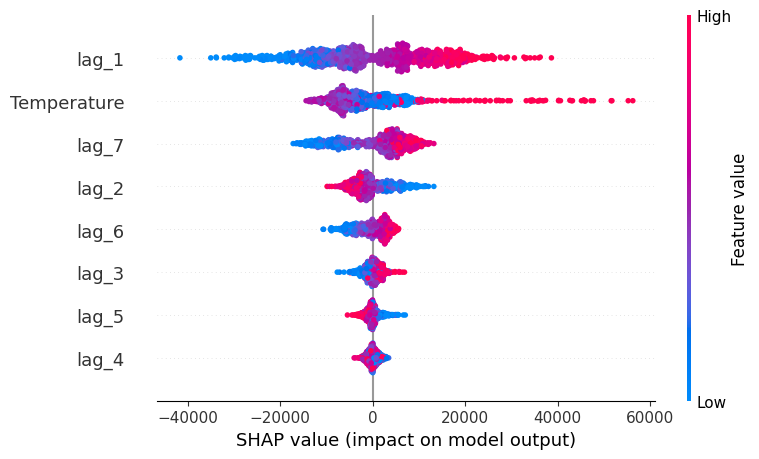

In [80]:
shap.summary_plot(shap_values, X_train)

**Hasil Output:**

Plot dot/beeswarm menampilkan distribusi SHAP value untuk setiap fitur dengan informasi arah pengaruh:

Pembacaan hasil dari plot:

- `lag_1`: titik-titik merah (nilai lag_1 tinggi) menyebar ke kanan (SHAP positif) hingga +60.000, dan titik biru (lag_1 rendah) menyebar ke kiri (SHAP negatif) hingga -40.000. Artinya: demand kemarin tinggi cenderung meningkatkan prediksi hari ini, dan sebaliknya.

- `Temperature`: titik merah (suhu tinggi) cenderung di sisi kanan (SHAP positif), titik biru (suhu rendah) cenderung di sisi kiri. Suhu tinggi meningkatkan prediksi demand, suhu rendah menurunkannya.

- `lag_7`: pola serupa namun dengan sebaran lebih sempit, menunjukkan pengaruh pola mingguan yang lebih moderat.

- Fitur `lag_3` hingga `lag_5` memiliki sebaran SHAP yang sangat sempit di sekitar 0, menunjukkan pengaruh yang relatif kecil dan konsisten.

## Langkah 12 - SHAP Force Plot: Satu Observasi (Local Explainability)

Force plot menjelaskan prediksi model untuk **satu data point secara individual**.

Cara membaca force plot:
- **Base value**: nilai prediksi rata-rata model di seluruh data training (baseline)
- **Output value**: prediksi aktual model untuk observasi ini
- **Fitur berwarna merah**: mendorong prediksi ke atas (meningkatkan demand)
- **Fitur berwarna biru**: mendorong prediksi ke bawah (menurunkan demand)
- Lebar segmen menunjukkan besarnya kontribusi fitur tersebut

Ini adalah bentuk **local explainability**: menjawab pertanyaan 'Mengapa model memprediksi nilai X untuk hari ini?'

In [81]:
import shap
shap.initjs()

# Force plot for the first observation
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

**Hasil Output:**

Force plot berhasil dirender karena `shap.initjs()` dipanggil ulang di cell ini.

Plot menampilkan visualisasi horizontal yang menjelaskan prediksi model untuk **1 data point** pada tanggal 7 Januari 2012.

Cara membaca force plot:

| Elemen | Keterangan |
|---|---|
| **base value** | Nilai rata-rata prediksi model di seluruh data training (~207.000 MWh) |
| **output value** | Nilai prediksi aktual model untuk observasi ini (~200.693 MWh) |
| Segmen **merah** (kanan) | Fitur yang mendorong prediksi naik dari baseline |
| Segmen **biru** (kiri) | Fitur yang mendorong prediksi turun dari baseline |
| Lebar segmen | Besarnya kontribusi fitur tersebut |

**Interpretasi untuk observasi 7 Januari 2012:**

Pada tanggal ini nilai lag_7 sangat rendah (82.531 MWh, yaitu 31 Desember 2011 yang hanya setengah hari data) sehingga mendorong prediksi turun secara signifikan (segmen biru dominan). Sementara lag_1 (205.338 MWh) dan Temperature (24.10 derajat C) memberikan kontribusi positif yang sebagian mengimbangi penurunan tersebut. Hasil akhir prediksi (200.693 MWh) berada di bawah baseline karena efek penurunan dari lag_7 yang anomali lebih besar dari efek kenaikan fitur lainnya.

Inilah kekuatan **local explainability**: kita dapat mengetahui secara tepat mengapa prediksi suatu hari bernilai demikian, bukan hanya angkanya saja.

## Langkah 13 - SHAP Force Plot: 200 Observasi

Force plot yang di-stack untuk 200 observasi pertama dari data training.

Kegunaan:
- Memperlihatkan pola pengaruh fitur secara agregat lintas banyak prediksi
- Memudahkan identifikasi: apakah ada kelompok prediksi tertentu yang didominasi fitur tertentu?
- Berguna untuk menemukan segmen data dengan perilaku model yang berbeda

Sumbu horizontal bisa diurutkan berdasarkan waktu atau nilai prediksi untuk melihat pola yang berbeda.

In [82]:
# Force plot for the first 200 observations in the training set
# ==============================================================================

import shap
shap.initjs()


shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

**Hasil Output:**

Plot menampilkan **200 force plot yang di-stack** secara vertikal, mewakili periode Januari 2012 hingga pertengahan Juli 2012.

**Cara membaca stacked force plot:**

- Sumbu horizontal: waktu (urutan 200 observasi)
- Warna merah: fitur-fitur yang secara agregat mendorong prediksi di atas baseline
- Warna biru: fitur-fitur yang secara agregat mendorong prediksi di bawah baseline
- Ketebalan warna: besarnya kontribusi kumulatif fitur-fitur tersebut

**Pola yang terlihat pada 200 observasi awal:**

| Periode | Pola Dominan | Penjelasan |
|---|---|---|
| Januari–Februari 2012 | Merah tebal (Temperature tinggi) | Puncak musim panas Australia, suhu tinggi mendorong demand naik |
| Maret–April 2012 | Transisi merah ke biru | Pergantian musim, suhu menurun |
| Mei–Juli 2012 | Biru dominan | Musim dingin, demand lebih rendah dari baseline |

**Nilai penting dari visualisasi ini:**
Stacked force plot mengungkap **pola musiman** yang tidak terlihat dari satu force plot saja. Kita dapat melihat secara visual bahwa model berperilaku berbeda di musim panas vs musim dingin, dan kontributor utamanya adalah Temperature yang berubah mengikuti siklus musiman Australia.

## Langkah 14 - SHAP Dependence Plot: Temperature

Dependence plot menggambarkan hubungan antara **nilai aktual suatu fitur** dengan **SHAP value-nya**.

Cara membaca:
- Sumbu X: nilai Temperature aktual
- Sumbu Y: SHAP value untuk fitur Temperature pada setiap observasi
- Warna titik: nilai fitur interaksi yang dipilih otomatis oleh SHAP (biasanya fitur yang paling berinteraksi)

Dari plot ini kita dapat mengidentifikasi:
1. Apakah hubungan Temperature dengan prediksi bersifat linear atau non-linear?
2. Pada rentang suhu berapa pengaruhnya paling besar?
3. Apakah ada efek interaksi antara Temperature dengan fitur lain?

Secara intuitif: pada suhu sangat panas atau sangat dingin, penggunaan listrik untuk pendingin/pemanas meningkat signifikan, sehingga SHAP value Temperature cenderung positif di kedua ekstrem.

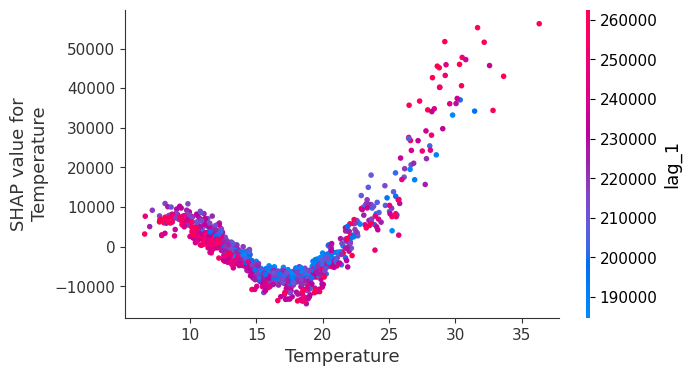

In [83]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

**Hasil Output:**

Plot scatter menampilkan hubungan antara nilai Temperature aktual (sumbu X) dengan SHAP value untuk Temperature (sumbu Y). Warna titik mewakili nilai lag_1.

**Pembacaan hasil:**

- Pada suhu rendah (sekitar 10-15 derajat C): SHAP value Temperature berkisar -10.000 hingga 0, artinya suhu dingin menurunkan prediksi demand.
- Pada suhu sedang (15-22 derajat C): SHAP value mendekati 0, pengaruh suhu netral.
- Pada suhu tinggi (di atas 25 derajat C): SHAP value meningkat tajam hingga +50.000, artinya suhu panas sangat meningkatkan prediksi demand.

**Kesimpulan plot ini:**

Hubungan antara Temperature dan demand bersifat **non-linear** dengan bentuk seperti huruf J. Suhu ekstrem (sangat panas) memiliki dampak jauh lebih besar dibanding suhu dingin. Ini konsisten dengan iklim Victoria, Australia, di mana penggunaan AC saat gelombang panas mendominasi lonjakan permintaan listrik.

## Langkah 15 - Melakukan Prediksi

Setelah model dilatih, kita melakukan prediksi untuk 10 hari ke depan menggunakan `forecaster.predict()`.

Parameter:
- `steps = 10`: prediksi dilakukan untuk 10 langkah (10 hari) ke depan
- `exog = data_test['Temperature']`: menyediakan nilai suhu aktual untuk hari-hari yang diprediksi

In [84]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


**Hasil Output:**

Model berhasil menghasilkan prediksi permintaan listrik untuk 10 hari ke depan:

Interpretasi:
- Demand tertinggi diprediksi pada 22 Desember (241.514 MWh) yang bertepatan dengan awal musim panas di Australia, kemungkinan didorong oleh suhu tinggi.
- Terjadi penurunan signifikan pada 26 Desember (184.885 MWh) yang merupakan Boxing Day — hari libur nasional — sehingga aktivitas industri menurun.
- Prediksi mulai kembali naik setelah 27 Desember seiring kembalinya aktivitas normal.

## Langkah 16 - Membuat Matriks Input untuk Prediksi

`create_predict_X()` menampilkan secara eksplisit matriks fitur yang digunakan model saat melakukan prediksi untuk setiap langkah.

Kegunaan:
- Transparansi: kita dapat melihat input yang sebenarnya digunakan model
- Verifikasi: memastikan lag terisi dengan benar (campuran nilai aktual dan prediksi rekursif)
- Prerequisite untuk SHAP pada data prediksi: matriks ini yang akan diberikan ke SHAP explainer

Ini adalah langkah penting untuk melakukan explainability pada prediksi masa depan, bukan hanya pada data training.

In [85]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


**Hasil Output:**

Tabel menampilkan nilai lag dan Temperature yang digunakan model untuk setiap langkah prediksi.

Interpretasi:
- Untuk prediksi 22 Desember, `lag_1` (216.483) adalah nilai Demand aktual terakhir dari data training.
- Untuk prediksi 23 Desember, `lag_1` (241.514) adalah hasil prediksi hari sebelumnya — bukan nilai aktual. Inilah mekanisme rekursif yang terjadi.
- Temperature untuk setiap hari diambil dari data test (nilai aktual/prakiraan cuaca).
- Transparansi ini memungkinkan kita mengetahui persis input apa yang digunakan model, sehingga SHAP dapat diterapkan pada matriks ini.

## Langkah 17 - SHAP Force Plot untuk Prediksi Spesifik

Bagian ini menerapkan SHAP untuk menjelaskan prediksi model pada **tanggal spesifik di masa depan** (22 Desember 2014).

Proses:
1. Ambil matriks input prediksi (`X_predict`) dari langkah sebelumnya
2. Tentukan indeks tanggal yang ingin dijelaskan
3. Hitung SHAP values menggunakan explainer yang sama
4. Tampilkan force plot untuk baris tersebut

Perbedaan dengan force plot pada data training:
- Lag yang digunakan sebagian mungkin berasal dari prediksi rekursif (bukan nilai aktual)
- Ini memperlihatkan secara transparan bagaimana ketidakpastian lag berpropagasi ke dalam penjelasan prediksi

Pertanyaan yang dijawab: 'Mengapa model memprediksi demand sebesar X MWh pada tanggal 22 Desember 2014?'

In [86]:
# Force plot for a specific prediction
# ==============================================================================
import shap
shap.initjs()

predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

**Hasil Output:**

Plot menjelaskan prediksi model untuk tanggal **22 Desember 2014** (hari pertama dari data test, langkah prediksi pertama).

**Hasil prediksi: 241.514,53 MWh**

**Interpretasi force plot:**

- **lag_1** (216.483 MWh) memberikan kontribusi positif terbesar karena nilainya cukup tinggi dibanding baseline — demand kemarin yang tinggi mendorong prediksi naik.
- **Temperature** (22.95 derajat C) juga berkontribusi positif karena suhu pertengahan musim panas Australia mendorong penggunaan AC.
- **lag_7** (231.923 MWh) turut berkontribusi positif karena demand 7 hari lalu (15 Desember 2014) juga tinggi, mencerminkan pola mingguan.
- Kombinasi ketiga faktor ini mendorong prediksi jauh di atas baseline (~207.000 MWh) sehingga menghasilkan prediksi 241.514 MWh.

**Perbedaan penting dengan force plot training:**
Pada prediksi ini, nilai lag sebagian besar masih berasal dari data aktual (karena ini langkah pertama prediksi). Pada langkah prediksi berikutnya (23 Des dst), lag_1 sudah merupakan hasil prediksi rekursif, sehingga ketidakpastian mulai bertambah.

## Langkah 18 - Permutation Importance
Permutation Importance adalah metode alternatif untuk mengukur kepentingan fitur. Berbeda dengan feature importance bawaan LightGBM yang berbasis struktur pohon internal, Permutation Importance mengukur dampak langsung terhadap performa model.

**Cara Kerja:**

1. Latih model dan ukur performa baseline (misalnya: MSE = 100)
2. Acak (shuffle) nilai satu fitur secara acak, buat prediksi ulang
3. Ukur penurunan performa (misalnya: MSE menjadi 350 setelah lag_1 diacak)
4. Selisih performa = kepentingan fitur tersebut
5. Ulangi untuk setiap fitur


Fitur yang paling menurunkan performa saat nilainya diacak adalah fitur paling penting.

**Keunggulan vs Feature Importance Bawaan**

| Aspek | Feature Importance (LightGBM) | Permutation Importance |
|---|---|---|
| Dasar perhitungan | Struktur pohon internal (gain) | Perubahan performa aktual |
| Bias kardinalitas | Ya (fitur dengan banyak nilai unik cenderung lebih tinggi) | Tidak |
| Model-agnostic | Tidak (khusus tree-based) | Ya |
| Biaya komputasi | Rendah | Lebih tinggi (perlu re-predict) |

Parameter `n_repeats=3` berarti proses pengacakan diulang 3 kali untuk mendapatkan estimasi yang lebih stabil, dan `max_samples=0.5` berarti hanya menggunakan 50% data untuk efisiensi.

In [87]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.regressor,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


**Hasil Output:**

Tabel menampilkan kepentingan fitur berdasarkan penurunan performa saat nilai diacak, diurutkan dari yang tertinggi.

Interpretasi:
- `lag_1` kembali muncul sebagai fitur paling kritis (0.617): jika nilai kemarin diacak, performa model turun paling drastis. Ini konsisten dengan hasil SHAP.
- `Temperature` di urutan kedua (0.411): pengaruhnya sangat signifikan dan hampir setara dengan lag_1.
- `lag_7` di urutan ketiga (0.196) menunjukkan pola mingguan memang relevan, meskipun lebih lemah dibanding data terbaru.
- Nilai std_importance yang kecil (di bawah 0.015) menunjukkan hasil yang stabil dan konsisten di ketiga pengulangan (n_repeats=3).
- Ketiga metode (Feature Importance, SHAP, Permutation Importance) secara konsisten menempatkan lag_1 dan Temperature sebagai dua fitur terpenting, yang memperkuat validitas kesimpulan.

## Langkah 19 - Partial Dependence Plot (PDP)

PDP menggambarkan **pengaruh marginal rata-rata** suatu fitur terhadap prediksi model, dengan cara menetapkan semua fitur lain pada nilai rata-ratanya.

Cara Kerja:

Untuk fitur Temperature dengan nilai rentang [10, 15, 20, 25, 30]:
1. Set seluruh nilai Temperature di dataset menjadi 10, buat semua prediksi, hitung rata-rata
2. Ulangi untuk Temperature = 15, 20, 25, 30
3. Plot nilai rata-rata prediksi vs nilai fitur tersebut

Hasilnya adalah kurva yang menunjukkan bagaimana demand berubah seiring perubahan Temperature, dengan pengaruh fitur lain 'dineutralkan'.

Parameter `kind='both'` Menampilkan dua jenis plot sekaligus:
- **PDP** (garis tebal): rata-rata pengaruh fitur di seluruh observasi
- **ICE - Individual Conditional Expectation** (garis tipis abu-abu): pengaruh fitur untuk setiap observasi secara individual

ICE penting karena PDP bisa menyembunyikan heterogenitas — jika sebagian observasi bereaksi positif dan sebagian bereaksi negatif terhadap kenaikan fitur, rata-rata PDP akan terlihat datar padahal ada efek besar.

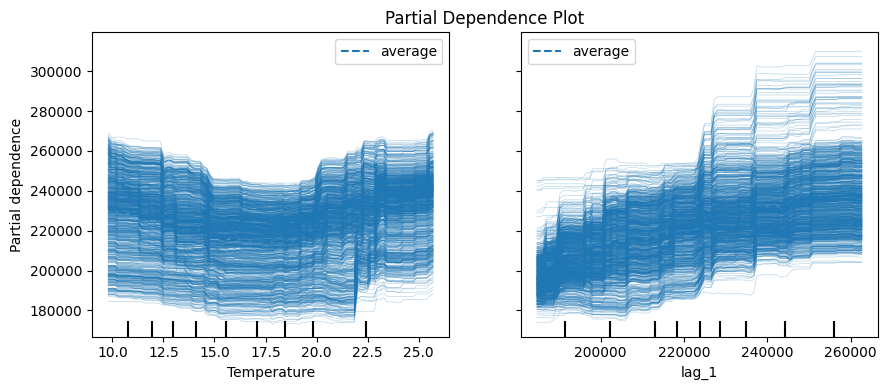

In [88]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.regressor,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

**Hasil Output:**

Plot menampilkan dua panel PDP dengan ICE untuk fitur Temperature dan lag_1.

**Panel kiri (Temperature:)**
- Garis PDP rata-rata (tebal) menunjukkan hubungan non-linear: demand meningkat seiring naiknya suhu, terutama di atas 25 derajat C.
- Garis ICE (tipis abu-abu) menunjukkan sebagian besar observasi mengikuti pola yang sama, namun ada beberapa yang bereaksi lebih ekstrem pada suhu sangat tinggi.

**Panel kanan (lag_1):**
- Garis PDP menunjukkan hubungan yang hampir linear positif: semakin tinggi demand kemarin, semakin tinggi prediksi demand hari ini.
- Garis ICE relatif seragam, menunjukkan hampir semua observasi bereaksi secara homogen terhadap perubahan lag_1.

**Kesimpulan dari PDP:**
Kedua fitur terpenting memiliki hubungan positif dengan target. Temperature bersifat non-linear (efek lebih kuat di suhu tinggi), sedangkan lag_1 bersifat hampir linear. Tidak ada efek interaksi tersembunyi yang terdeteksi dari ICE plot ini.

# Analisis dan Kesimpulan Seluruh Tahapan

Analisis dilakukan untuk memprediksi permintaan listrik harian di Victoria, Australia menggunakan model LightGBM dengan Skforecast. Dataset yang digunakan berisi data permintaan listrik dan suhu udara yang kemudian diubah dari interval 30 menit menjadi data harian agar pola lebih mudah dipelajari.

Data dibagi menjadi data training dan testing menggunakan metode time-series split. Model dibangun dengan memanfaatkan 7 nilai permintaan listrik sebelumnya (lag_1 sampai lag_7) serta suhu harian (Temperature) sebagai fitur untuk memprediksi permintaan listrik hari berikutnya.

Hasil analisis menunjukkan bahwa **lag_1 (permintaan listrik hari sebelumnya)** dan **Temperature (suhu harian)** merupakan faktor yang paling berpengaruh terhadap prediksi. Semakin tinggi permintaan listrik pada hari sebelumnya dan semakin tinggi suhu udara, maka prediksi permintaan listrik cenderung meningkat.

Untuk memahami cara model bekerja, digunakan beberapa metode Explainable AI seperti Feature Importance, SHAP, Permutation Importance, dan Partial Dependence Plot (PDP). Seluruh metode memberikan hasil yang konsisten bahwa lag_1 dan Temperature merupakan fitur terpenting dalam model.

## Kesimpulan Seluruh Tahapan

Model berhasil memprediksi permintaan listrik harian berdasarkan pola historis konsumsi listrik dan suhu udara. Faktor yang paling memengaruhi hasil prediksi adalah permintaan listrik hari sebelumnya (lag_1) dan suhu harian (Temperature). Penerapan Explainable AI membantu menjelaskan alasan di balik setiap prediksi sehingga model menjadi lebih transparan dan mudah dipahami.

# Jawaban Pertanyaaan Tugas
## 1. Analisis Prediksi Tentang Apa?

Analisis ini melakukan prediksi **permintaan listrik harian (electricity demand)** di negara bagian Victoria, Australia, dalam satuan MWh (Megawatt-hour).

Model dibangun untuk menjawab pertanyaan:
> Berdasarkan pola konsumsi listrik 7 hari terakhir dan data suhu udara, berapa total permintaan listrik yang akan terjadi pada hari-hari berikutnya?

Analisis ini tidak hanya berhenti pada prediksi angka, tetapi juga menerapkan pendekatan **Explainable AI (XAI)** untuk menjelaskan mengapa model menghasilkan prediksi tertentu. Hal ini penting dalam konteks manajemen energi, karena pengelola jaringan listrik perlu memahami faktor apa yang mendorong lonjakan atau penurunan permintaan listrik.

---

## 2. Bentuk Data Training: Input dan Output

Data time series permintaan listrik ditransformasi menjadi format supervised learning oleh Skforecast melalui mekanisme lag. Setiap baris data training mewakili satu hari prediksi.

### Input (X_train) — 8 Fitur

| Nama Fitur | Sumber Data | Keterangan |
|---|---|---|
| lag_1 | Demand pada hari t-1 | Permintaan listrik kemarin |
| lag_2 | Demand pada hari t-2 | Permintaan listrik 2 hari lalu |
| lag_3 | Demand pada hari t-3 | Permintaan listrik 3 hari lalu |
| lag_4 | Demand pada hari t-4 | Permintaan listrik 4 hari lalu |
| lag_5 | Demand pada hari t-5 | Permintaan listrik 5 hari lalu |
| lag_6 | Demand pada hari t-6 | Permintaan listrik 6 hari lalu |
| lag_7 | Demand pada hari t-7 | Permintaan listrik 7 hari lalu (1 minggu lalu) |
| Temperature | Suhu rata-rata hari t | Variabel eksogen (exogenous variable) |

### Output (y_train) — 1 Target

| Nama Kolom | Keterangan |
|---|---|
| Demand | Total permintaan listrik aktual pada hari t (dalam MWh) |

### Ilustrasi Satu Baris Data Training

```
INPUT:
  lag_1       = 185,420 MWh  (kemarin)
  lag_2       = 179,310 MWh  (2 hari lalu)
  lag_3       = 176,850 MWh  (3 hari lalu)
  lag_4       = 183,200 MWh  (4 hari lalu)
  lag_5       = 188,100 MWh  (5 hari lalu)
  lag_6       = 190,400 MWh  (6 hari lalu)
  lag_7       = 184,900 MWh  (7 hari lalu)
  Temperature = 24.3 C       (suhu hari ini)

OUTPUT (yang diprediksi):
  Demand      = 182,750 MWh  (permintaan listrik hari ini)
```

---

## 3. Apa itu Lag?

Lag adalah **nilai variabel target dari periode-periode sebelumnya** yang dijadikan fitur input untuk memprediksi nilai saat ini. Konsep lag merupakan cara Skforecast mengubah masalah forecasting time series menjadi masalah regresi standar.

Secara sederhana, lag menjawab pertanyaan: "Berapa nilai yang terjadi 1 hari lalu? 2 hari lalu? ... 7 hari lalu?" dan menjadikan semua jawaban itu sebagai bahan pertimbangan model.

### Ilustrasi Pembentukan Lag

```
Data asli (Demand harian):
  Senin    = 180,000 MWh
  Selasa   = 175,000 MWh
  Rabu     = 178,000 MWh
  Kamis    = 182,000 MWh
  Jumat    = 190,000 MWh
  Sabtu    = 170,000 MWh
  Minggu   = 165,000 MWh
  Senin*   = ??? (yang ingin diprediksi)

Fitur lag untuk prediksi Senin*:
  lag_1 = 165,000  (Minggu)
  lag_2 = 170,000  (Sabtu)
  lag_3 = 190,000  (Jumat)
  lag_4 = 182,000  (Kamis)
  lag_5 = 178,000  (Rabu)
  lag_6 = 175,000  (Selasa)
  lag_7 = 180,000  (Senin minggu lalu)
```

### Mengapa Dipilih lag = 7?

Permintaan listrik memiliki **pola siklus mingguan** yang kuat. Hari Senin cenderung memiliki pola konsumsi yang mirip dengan Senin minggu sebelumnya, begitu pula hari-hari lainnya. Dengan menggunakan 7 lag, model dapat menangkap siklus mingguan tersebut secara penuh.

Jumlah lag adalah bagian dari feature engineering dan dapat disesuaikan tergantung karakteristik data. Semakin banyak lag, semakin panjang memori model, namun juga semakin kompleks dan berisiko overfitting.

---

## 4. Proses Analisis yang Dilakukan

Berikut adalah penjelasan lengkap setiap tahap analisis dari awal hingga akhir:

### Tahap 1 - Persiapan Data

Dataset `vic_electricity` diunduh dari repositori Skforecast. Data asli memiliki interval 30 menit (48 baris per hari), kemudian diresample menjadi frekuensi harian dengan menjumlahkan Demand dan merata-rata Temperature per hari. Tujuannya adalah menyederhanakan pola agar lebih mudah dipelajari model dan mengurangi noise jangka pendek.

### Tahap 2 - Pembagian Data Train dan Test

Data dibagi secara kronologis (time-series split):
- Training set: seluruh data hingga 21 Desember 2014
- Test set: data mulai 22 Desember 2014

Pembagian kronologis wajib dilakukan pada data time series untuk menghindari data leakage — model tidak boleh melihat data masa depan saat proses training.

### Tahap 3 - Membangun dan Melatih Model

Dibuat sebuah `ForecasterRecursive` dengan konfigurasi:
- Regressor: LGBMRegressor (LightGBM)
- Lags: 7 (menggunakan 7 hari ke belakang sebagai fitur)
- Exogenous variable: Temperature

Skforecast secara otomatis membentuk matriks X_train dan y_train dari data Demand menggunakan mekanisme lag, lalu melatih LightGBM pada matriks tersebut.

### Tahap 4 - Prediksi

Model memprediksi permintaan listrik untuk 10 hari ke depan secara rekursif. Pada setiap langkah prediksi, hasil prediksi langkah sebelumnya digunakan sebagai nilai lag untuk langkah berikutnya. Nilai Temperature untuk hari-hari yang diprediksi disediakan dari data test (dalam praktik nyata menggunakan prakiraan cuaca).

### Tahap 5 - Explainability: Feature Importance (LightGBM)

Kepentingan fitur dihitung menggunakan metode gain bawaan LightGBM. Nilai ini menunjukkan seberapa besar kontribusi setiap fitur dalam mengurangi error pada seluruh pohon keputusan yang dibangun model. Ini memberikan gambaran global fitur mana yang paling sering dan paling signifikan digunakan oleh model.

### Tahap 6 - Explainability: SHAP Values

SHAP (SHapley Additive exPlanations) digunakan untuk penjelasan yang lebih mendalam:

- **Summary Bar Plot**: menampilkan rata-rata absolut SHAP value tiap fitur, gambaran global kepentingan fitur
- **Summary Beeswarm Plot**: menampilkan distribusi SHAP value lengkap dengan arah pengaruh (positif/negatif) dan hubungannya dengan nilai fitur
- **Force Plot (1 observasi)**: menjelaskan secara lokal mengapa model memprediksi nilai tertentu untuk satu hari spesifik
- **Force Plot (200 observasi)**: force plot yang di-stack untuk melihat pola pengaruh fitur secara agregat
- **Dependence Plot (Temperature)**: memperlihatkan hubungan antara nilai Temperature aktual dengan SHAP value-nya
- **Force Plot prediksi spesifik**: SHAP diterapkan pada matriks prediksi untuk menjelaskan prediksi tanggal 22 Desember 2014

### Tahap 7 - Explainability: Permutation Importance

Sebagai metode alternatif, Permutation Importance mengukur kepentingan fitur dengan cara mengacak nilai setiap fitur satu per satu dan mengukur penurunan performa model. Metode ini lebih robust dibanding feature importance bawaan karena berbasis perubahan performa aktual, bukan struktur internal pohon.

### Tahap 8 - Explainability: Partial Dependence Plot (PDP)

PDP menggambarkan pengaruh marginal rata-rata suatu fitur (Temperature dan lag_1) terhadap prediksi, dengan menetapkan semua fitur lain pada nilai rata-ratanya. Dengan parameter `kind=both`, plot juga menampilkan Individual Conditional Expectation (ICE) yang memperlihatkan apakah setiap observasi bereaksi secara seragam atau heterogen terhadap perubahan fitur tersebut.

---

### Diagram Alur Analisis

```
Dataset vic_electricity (interval 30 menit)
         |
         v
Agregasi Harian (Demand: sum, Temperature: mean)
         |
         v
Pembagian Data
  Train: s/d 21 Des 2014
  Test : 22 Des 2014 dst
         |
         v
Membangun ForecasterRecursive
  Model : LightGBM
  Lag   : 7
  Exog  : Temperature
         |
         v
Training Model
  X_train : lag_1...lag_7 + Temperature
  y_train : Demand
         |
         v
Prediksi 10 Hari ke Depan (Rekursif)
         |
         v
Explainability Analysis
  |-- Feature Importance (LightGBM, berbasis gain)
  |-- SHAP Global    : Summary Bar Plot + Beeswarm Plot
  |-- SHAP Lokal     : Force Plot (1 obs, 200 obs, prediksi spesifik)
  |-- SHAP Fitur     : Dependence Plot (Temperature)
  |-- Permutation Importance (model-agnostic, berbasis performa)
  |-- Partial Dependence Plot (Temperature + lag_1, dengan ICE)


## Kesimpulan Akhir

Berdasarkan seluruh tahapan analisis, model forecasting menggunakan Skforecast dan LightGBM berhasil digunakan untuk memprediksi permintaan listrik harian di Victoria, Australia. Model memanfaatkan data historis permintaan listrik selama 7 hari sebelumnya (lag) serta suhu rata-rata harian (Temperature) untuk menghasilkan prediksi.

Hasil interpretasi menggunakan Feature Importance, SHAP, Permutation Importance, dan Partial Dependence Plot menunjukkan bahwa faktor yang paling memengaruhi prediksi adalah **permintaan listrik hari sebelumnya (lag_1)** dan **suhu harian (Temperature)**. Selain itu, pola mingguan yang direpresentasikan oleh **lag_7** juga memberikan kontribusi terhadap hasil prediksi.

Penerapan Explainable AI (XAI) berhasil memberikan pemahaman yang lebih jelas mengenai cara model menghasilkan prediksi, baik secara global maupun pada prediksi individual. Dengan demikian, model tidak hanya mampu melakukan prediksi permintaan listrik, tetapi juga dapat menjelaskan faktor-faktor yang memengaruhi hasil prediksi sehingga lebih transparan, mudah dipahami, dan dapat dipercaya dalam pengambilan keputusan.